# 📝🤖 Atividade Avaliativa - Classificação de Textos usando *Word Embeddings* e LSTMs


Esta atividade tem como objetivo praticar o uso de *word embeddings* pré-treinados e redes neurais baseadas em LSTMs para classificação de textos. Será utilizada a base de dados [BBC News Archive](https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive) que possui 2225 notícias organizadas nas classes '*business*', '*entertainment*', '*politics*', '*sport*' e '*tech*'.


**As atividades que devem ser realizadas estão nos tópicos:**
- Atividade 1: Pré-Processamento
- Atividade 2: Aplicação de Padding nas Sequências
- Atividade 3: Definição do Modelo
- Atividade 4: Análise dos Resultados


## Preparação do Ambiente e Imports de Bibliotecas

In [1]:

import os
import re

import torch
import unidecode
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import gensim.downloader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Ativa o tqdm nas operações do pandas
tqdm.pandas()
# configura o estilo dos plots
sns.set_style('darkgrid')


## Download do Dataset

Vamos utilizar a biblioteca *kagglehub* para fazer o download do dataset e a biblioteca pandas para ler o arquivo `.csv` em um *data frame* e embaralhá-lo.

In [2]:
ds_path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")
csv_path = os.path.join(ds_path, 'bbc-news-data.csv')
df = pd.read_csv(csv_path, sep= '\t')
df = df.sample(frac=1)
df

100%|██████████| 1.81M/1.81M [00:00<00:00, 2.08MB/s]

Extracting files...


,category,filename,title,content
367,business,368.txt,Warning over US pensions deficit,Taxpayers may have to bail out the US agency ...
1641,sport,329.txt,"Umaga ready for ""fearsome"" Lions",All Blacks captain Tama Umaga has warned the ...
413,business,414.txt,Enron bosses in $168m payout,Eighteen former Enron directors have agreed a...
2117,tech,294.txt,Games win for Blu-ray DVD format,The next-generation DVD format Blu-ray is win...
1553,sport,241.txt,Hamm bows out for US,Women's football legend Mia Hamm has played h...
...,...,...,...,...
1510,sport,198.txt,Edu describes tunnel fracas,Arsenal's Edu has lifted the lid on the scene...
1504,sport,192.txt,Redknapp's Saints face Pompey tie,New Southampton manager Harry Redknapp faces ...
270,business,271.txt,Arsenal 'may seek full share listing',Arsenal vice-chairman David Dein has said the...
2147,tech,324.txt,Apple attacked over sources row,Civil liberties group the Electronic Frontier...


## Atividade 1: Pré-Processamento

Use a biblioteca gensim para fazer o download de um modelo de word embeddings pré-treinado. Fique à vontade para escolher diferentes modelos e avaliar suas performances.

In [3]:
# #### ADICIONE SUA RESPOSTA AQUI ####

# testados: glove-twitter (100 e 50) e glove-wiki-gigaword (100 e 50)
we_model = gensim.downloader.load("glove-wiki-gigaword-100") 
we_model

[=========-----------------------------------------] 18.3% 23.4/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[=======================================-----------] 78.3% 100.2/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Usando o modelo de *word embeddings*, mostre quais palavras são mais próximas ao termo "economy".

In [4]:
# #### ADICIONE SUA RESPOSTA AQUI ####

we_model.most_similar("economy")

[('economic', 0.8278784155845642),
 ('growth', 0.7946652770042419),
 ('recession', 0.7692252397537231),
 ('economies', 0.7545282244682312),
 ('recovery', 0.749137282371521),
 ('downturn', 0.746234118938446),
 ('slowdown', 0.7368298768997192),
 ('slowing', 0.7281357049942017),
 ('sector', 0.7247328162193298),
 ('crisis', 0.7135800719261169)]

Use o modelo de *word embeddings* para recuperar o embedding associado à palavra "championship". 

In [5]:
# #### ADICIONE SUA RESPOSTA AQUI ####
we_model["championship"]

array([-0.042128 , -0.47788  ,  1.0892   , -0.43514  , -0.46796  ,
       -0.17639  ,  0.7789   ,  0.50304  , -0.78917  , -0.37095  ,
        0.55836  , -0.18275  , -0.39957  , -0.17314  , -0.72944  ,
        0.18856  ,  0.59633  ,  0.50136  , -0.34646  , -0.13366  ,
        0.12079  ,  0.056548 ,  0.62326  ,  0.65778  ,  0.37476  ,
       -0.39957  , -0.11279  , -1.0262   ,  0.91265  , -0.38754  ,
       -0.8912   ,  0.29699  , -0.36011  , -0.25808  ,  1.0317   ,
       -0.44623  , -0.90501  ,  1.1459   , -1.2297   ,  0.56701  ,
        0.45074  , -0.44656  ,  0.69197  , -0.9416   ,  0.068462 ,
        0.37151  ,  1.1694   , -0.13333  , -0.55792  , -1.1614   ,
       -1.3364   , -0.3646   , -0.083682 ,  0.71496  ,  1.0994   ,
       -2.6588   , -0.46187  ,  0.4321   ,  0.30795  ,  1.0383   ,
       -0.80232  ,  0.46333  , -0.20949  ,  0.11369  ,  0.15942  ,
       -0.65053  , -0.65184  ,  0.76229  ,  0.0066009,  0.33305  ,
       -0.37863  , -0.28991  , -0.3174   ,  0.10645  , -0.5958

Implemente uma função de pré-processamento que realize as operações indicadas nos comentários da função abaixo.


In [6]:
# #### ADICIONE SUA RESPOSTA AQUI ####

MAX_SEQ_LENGTH = 200

def preprocessing(text):
    # Use a biblioteca `unidecode` para substituir caracteres com sinais
    # (acentos, cedilha, etc.) por suas versões sem sinal
    text = unidecode.unidecode(text)

    # Use a biblioteca `re` para substituir caracteres não-alfanuméricos por espaço
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)

    # Converta o texto para minúsculo
    text = text.lower()

    # Separe o texto em palavras usando o método `split`
    words = text.split()

    # Limite o tamanho da sequencia para o tamanho máximo definido
    # em MAX_SEQ_LENGTH  para reduzir o custo computacional
    words = words[:MAX_SEQ_LENGTH]

    # Converta as palavras em word embeddings usando o modelo da biblioteca gensin criado acima.
    # Lembre-se de verificar se as palavras existem no modelo e ignore aquelas que não existem.
    # Por fim, lembre-se de converter o resultado em um torch.tensor.
    embds = torch.tensor(np.array([we_model[word] for word in words if word in we_model]))

    return embds


# executa a função de pré-processamento para o primeiro texto
print(preprocessing(df['content'].iloc[0]))


tensor([[-0.0563,  0.7416,  0.5695,  ...,  0.4253,  0.5948, -0.7064],
        [ 0.0825, -0.0753,  0.0147,  ..., -0.9202,  0.3685, -0.3865],
        [ 0.1571,  0.6561,  0.0021,  ..., -0.6061,  0.7100,  0.4147],
        ...,
        [-0.1529, -0.2428,  0.8984,  ..., -0.5910,  1.0039,  0.2066],
        [ 0.3311,  0.1936,  0.1661,  ..., -0.3390,  0.5935, -0.0168],
        [ 0.4931,  0.1462, -0.5077,  ...,  0.2778,  0.8284,  0.5421]])


A célula abaixo aplica a função de pré-processamento para toda a base de dados. 

In [7]:
x = [preprocessing(t) for t in df['content']]
x

[tensor([[-0.0563,  0.7416,  0.5695,  ...,  0.4253,  0.5948, -0.7064],
         [ 0.0825, -0.0753,  0.0147,  ..., -0.9202,  0.3685, -0.3865],
         [ 0.1571,  0.6561,  0.0021,  ..., -0.6061,  0.7100,  0.4147],
         ...,
         [-0.1529, -0.2428,  0.8984,  ..., -0.5910,  1.0039,  0.2066],
         [ 0.3311,  0.1936,  0.1661,  ..., -0.3390,  0.5935, -0.0168],
         [ 0.4931,  0.1462, -0.5077,  ...,  0.2778,  0.8284,  0.5421]]),
 tensor([[-0.2182,  0.6920,  0.7044,  ..., -0.3797,  0.6828,  0.6388],
         [ 0.2570,  0.9186,  0.4088,  ...,  0.3703, -0.0884,  0.2113],
         [-0.2997, -0.3013,  0.3723,  ..., -0.2376, -1.2381, -0.5948],
         ...,
         [-0.0293,  0.3283, -0.2525,  ...,  0.1999,  0.7803,  0.3920],
         [ 0.2147,  0.4337,  0.3396,  ...,  0.0466,  0.8300,  0.4030],
         [-0.0093,  0.1869,  0.0843,  ...,  0.7018,  0.5655, -0.4341]]),
 tensor([[ 0.1024,  0.6951, -0.2239,  ...,  0.2464,  0.2015, -0.1924],
         [-0.1133,  0.0294,  0.7302,  ...,  0

## Atividade 2: Aplicação de Padding nas Sequências

Utilize a operação de *padding* para uniformizar o tamanho das sequências armazenadas na variável `x`. [Leia mais sobre a função pad_sequence](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html).

In [8]:
from torch.nn.utils.rnn import pad_sequence

# #### ADICIONE SUA RESPOSTA AQUI ###
x_padded = pad_sequence(x, batch_first=True)

x_padded.shape

torch.Size([2225, 200, 100])

## Divisão dos Dados em Conjuntos de Treino e Teste

Use a classe [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) da biblioteca scikit-learn para transformar os nomes das classes em labels inteiros. Em seguida, transforme a sequência de labels em um tensor.

In [9]:
# #### ADICIONE SUA RESPOSTA AQUI ####
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform([category for category in df['category']])
y = torch.tensor(y)
y

tensor([0, 3, 0,  ..., 0, 4, 0])

Use o objeto [LabelEncoder para mostrar a lista de classes identificadas](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html#:~:text=%3E%3E%3E%20list(-,le.classes_,-)%0A%5Bnp.str_).

In [10]:
# #### ADICIONE SUA RESPOSTA AQUI ####
le.classes_

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype='<U13')

A célula abaixo faz a divisão os dados em conjuntos de treino e teste. Não vamos usar um conjunto de validação para manter a atividade simples.

In [11]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_padded, y,
    test_size=0.2,
    random_state=42,
)

train_ds = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

test_ds = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_ds, batch_size=64)

print("train size:", len(train_ds), "test size:", len(test_ds))

train size: 1780 test size: 445


## Atividade 3: Definição do Modelo

Complete a definição da classe adicionando os itens especificados nos comentários abaixo.

In [12]:
# #### ADICIONE SUA RESPOSTA AQUI ####

from torch import nn

# Use o objeto LabelEncoder para recuperar o número de classes
n_classes = len(le.classes_)

class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # Crie uma camada LSTM
        self.lstm = nn.LSTM(
            input_size=100,     # embedding size
            hidden_size=64,
            bidirectional=False,
            batch_first=True,
        )

        self.dropout = nn.Dropout(0.3)
        
        # Crie uma camada totalmente conectada para classificação.
        # Lembre-se que o tamanho da entrada deve ser igual ao tamanho da LSTM.
        self.fc = nn.Linear(64, n_classes)

    def forward(self, sequence):
        # Passa a sequência de entrada pela LSTM
        _, (hidden, _) = self.lstm(sequence)

        # A saída da LSTM tem o shape [seq_length=1, batch_size, hidden_size].
        # Seq_length=1 porque apenas o estado da última posição da sequência é retornado.
        # A linha abaixo remove a dimensão da sequência fazendo com que o shape se torne [batch_size, hidden_size].
        hidden = hidden.squeeze(0)

        # passe a saída da LSTM pela camada totalmente conectada
        hidden = self.dropout(hidden)
        prediction = self.fc(hidden)

        return prediction

net = Model()
net(x_padded[:3])

tensor([[ 0.0852,  0.0934, -0.1306,  0.1651,  0.0959],
        [ 0.0559,  0.1398, -0.3078,  0.0916,  0.0753],
        [ 0.1027,  0.1243, -0.0848,  0.2016,  0.1138]],
       grad_fn=<AddmmBackward0>)

## Treinamento e Avaliação

A célula abaixo realiza o treinamento do modelo. Por simplicidade, utilizamos o conjunto de teste para avaliar a generalização do modelo ao longo do treinamento. **Em aplicações reais, o correto seria utilizar um conjunto independente de validação**.

In [13]:

import torch.optim as optim

net = Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-2)

history = []
n_epochs = 40

# repete por um número de épocas
for epoch in range(n_epochs):
    running_loss = 0.0

    # epoca de treinamento: itera sobre os batches do conjunto de treino
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data

        # Passos para treinamento de um batch
        # #### ADICIONE SUA RESPOSTA AQUI ####
        optimizer.zero_grad()
        outputs = net(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step();

        running_loss += loss.item()

    running_loss /= len(train_loader)

    # avaliação no conjunto de teste
    net.eval()
    test_loss = 0.0
    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data
            # Compute o erro para um batch de teste
            # #### ADICIONE SUA RESPOSTA AQUI ####
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

    test_loss /= len(train_loader)

    history.append([running_loss, test_loss])

    if epoch % max(1, n_epochs // 20)  == 0:
        print(f'[{epoch + 1}] loss: {running_loss:.4f} test loss: {test_loss:.4f}')

print('Finished Training')

[1] loss: 1.1931 test loss: 0.3901
[3] loss: 0.6242 test loss: 0.1492
[5] loss: 0.2780 test loss: 0.0940
[7] loss: 0.1923 test loss: 0.0955
[9] loss: 0.3851 test loss: 0.0738
[11] loss: 0.2061 test loss: 0.0780
[13] loss: 0.1157 test loss: 0.0662
[15] loss: 0.1143 test loss: 0.0652
[17] loss: 0.0547 test loss: 0.0704
[19] loss: 0.0295 test loss: 0.0779
[21] loss: 0.0173 test loss: 0.0884
[23] loss: 0.0110 test loss: 0.0743
[25] loss: 0.0071 test loss: 0.0860
[27] loss: 0.0047 test loss: 0.0934
[29] loss: 0.0147 test loss: 0.0913
[31] loss: 0.0435 test loss: 0.0816
[33] loss: 0.0500 test loss: 0.0591
[35] loss: 0.0231 test loss: 0.0449
[37] loss: 0.0141 test loss: 0.0776
[39] loss: 0.0074 test loss: 0.0827
Finished Training


A célula abaixo mostra a evolução da função de perda nos conjuntos de treino e teste. É esperado que ambas as curvas reduzam.

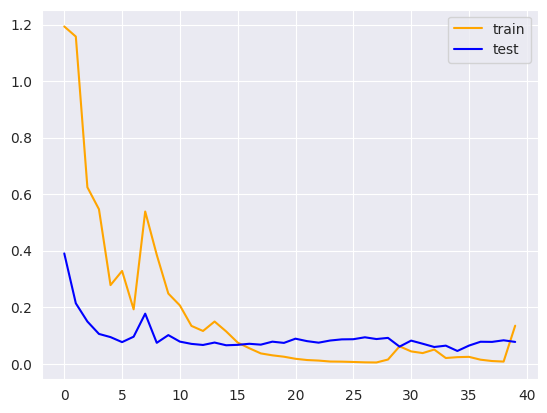

In [14]:
import matplotlib.pyplot as plt

history = np.array(history)

plt.plot(history[:, 0], '-', color='orange', label='train')
plt.plot(history[:, 1], '-', color='blue', label='test')
plt.legend()

Mostre as métricas de performance para o conjunto de teste usando a função classification_report da biblioteca scikit-learn. É possível alcançar uma acurácia superior a `95%`.

In [15]:
from sklearn.metrics import classification_report
net.eval()

# Itere sobre o conjunto de teste armazenando os labels verdadeiros e as predições
# #### ADICIONE SUA RESPOSTA AQUI ####
true_labels = []
preds = []
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        true_labels.extend(labels)
        preds.extend(list(np.argmax(outputs.cpu().detach().numpy(), axis=-1)))



print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       103
           1       0.99      0.93      0.96        87
           2       0.90      0.90      0.90        88
           3       0.99      0.96      0.97        92
           4       0.92      0.97      0.95        75

    accuracy                           0.94       445
   macro avg       0.94      0.94      0.94       445
weighted avg       0.94      0.94      0.94       445



A célula abaixo faz uma avaliação qualitativa do modelo do com um conjunto de textos. Verifique se o seu modelo identificou as classes corretamente.

**Importante:** Modifique a linha indicada com o seu objeto do tipo LabelEncoder.

In [16]:

softmax = torch.nn.Softmax(dim=-1)
net.eval()

def avalia_sentenca(texto):
    embds = preprocessing(texto)

    padded = torch.nn.functional.pad(embds, (0, 0, 0, MAX_SEQ_LENGTH - len(embds)), value=0.0)

    with torch.no_grad():
        padded = torch.unsqueeze(padded, 0)
        logits = net(padded)
        probs = softmax(logits)
        probs = np.squeeze(probs)
        cls = np.argmax(probs)

    print(f"Frase: {texto}")
    print(f"\nProbs: {probs}")

    # Use o objeto do tipo LabelEncoder para recuperar o nome da classe atribuída ao item
    # #### ADICIONE SUA RESPOSTA AQUI ####
    print(f"Class: {le.classes_[cls]}\n")

    print("------------\n")


# sport
avalia_sentenca("Liverpool have signed 18-year-old defender Giovanni Leoni from Italian side Parma for a fee of £26m plus add-ons. Leoni, who Reds boss Arne Slot confirmed the club had agreed a deal for earlier this week, has signed a contract until 2031. The Italy Under-19s centre-back began his career at Padova and had a short spell at Sampdoria before joining Parma last summer. Leoni played 17 games in his first campaign in Serie A last season, attracting interest from both Milan clubs, but has opted for a move abroad.")

# business
avalia_sentenca("Shares in Intel jumped by more than 7% on Thursday, following reports that the Trump administration is in talks to take a stake in the chipmaker. The reported deal would support the technology firm's plans to build a manufacturing hub in Ohio, according to Bloomberg, which said the size of the potential stake is not clear. White House spokesman Kush Desai said 'discussion about hypothetical deals should be regarded as speculation unless officially announced by the administration'.")

# tech
avalia_sentenca("Apple on Tuesday released its sixth developer beta of its mobile operating system, iOS 26, along with updates for iPad, Apple Watch, Apple TV, Mac, and others. As the new software gets closer to its September public launch date, the changes and tweaks aren't as significant, but there are still some surprises to be found. In beta 6, that includes a new selection of ringtones, a final decision on the Camera swiping direction controversy, a new onboarding experience, and other updates. There was quite a bit of backlash over the way Apple changed how the Camera mode switcher responds to touch. Users complained that the change, introduced in prior betas, broke their muscle memory, since the swipe gesture on this interface would reverse the scroll direction they were used to — which was the same design paradigm that all other native Apple apps use. In beta 5, Apple responded to these complaints by introducing a new Settings toggle that would allow you to switch back to 'Classic Mode', which would once again make the Camera app work like all others.")

# politics
avalia_sentenca("Watching the president of France and the prime minister close up was to see two men under the cosh, behind in the opinion polls and fighting for what they see as the essence of their political creed. It boils down to this - how do Sir Keir Starmer and Emmanuel Macron make the case for what they see as the virtues of patience, nuance, subtleties and trade-offs in an era of growing impatience at the perceived repeated failures of those in high office? There were just two lecterns and two speakers at the news conference the leaders hosted, but two other parties hovered in the air. Reform UK and National Rally, the party of Jordan Bardella and Marine Le Pen, were never mentioned explicitly. Nor were their leaders. But they were repeatedly mentioned implicitly.")


Frase: Liverpool have signed 18-year-old defender Giovanni Leoni from Italian side Parma for a fee of £26m plus add-ons. Leoni, who Reds boss Arne Slot confirmed the club had agreed a deal for earlier this week, has signed a contract until 2031. The Italy Under-19s centre-back began his career at Padova and had a short spell at Sampdoria before joining Parma last summer. Leoni played 17 games in his first campaign in Serie A last season, attracting interest from both Milan clubs, but has opted for a move abroad.

Probs: tensor([4.1627e-03, 1.0865e-03, 7.2224e-04, 9.9402e-01, 1.3245e-05])
Class: sport

------------

Frase: Shares in Intel jumped by more than 7% on Thursday, following reports that the Trump administration is in talks to take a stake in the chipmaker. The reported deal would support the technology firm's plans to build a manufacturing hub in Ohio, according to Bloomberg, which said the size of the potential stake is not clear. White House spokesman Kush Desai said 'discus

## Atividade 4: Análise dos Resultados

Responda as seguintes perguntas apresentando uma justificativa breve (poucas frases).

1. Considerando o gráfico de evolução da função de perda, responda as seguintes perguntas: 
   1. Existem indícios de *underfitting* (subajuste) do modelo?
   2. Existem indícios de *overfitting* (superajuste) do modelo?

2. Considerando os resultados da análise quantitativa, responda as seguintes perguntas: 
   1. O modelo apresentou uma boa generalização? 
   2. Em quais classes o modelo apresentou melhor e pior performance de acordo com o `f1-score`?

3. Quais conclusões podem ser tiradas com a análise qualitativa? 



---

1. 1. Não, o modelo não apresentou indícios de underfitting. A função de perda do modelo caiu consistentemente, exceto a alguns picos. Além disso, a perda no treinamento atingiu valores bem baixos, o quê indica que o modelo teve um bom aprendizado nos dados de treino.</br>
   2. Levemente. O modelo apresentou alguns indícios de overfitting leve. Especificamente, o fato da perda no teste ter atingido o mínimo na 13° época, e, no geral, aumentado a partir daí. Além disso, da 27° época em diante, a perda no treino cai, mas a do teste aumenta, apesar da flutuação. Esse aumento pequeno indica um leve overfitting do modelo.</br>
</br>
2. 1. Sim. Analisando o classification report, fica nítido que o modelo generaliza bem, tendo alcançado precision e recall superiores a 90% para todas as classes.</br>
   2. A classe onde o modelo apresentou a melhor performance foi, indiscutivelmente, a de esportes, alcançando surpreendentes 99% de f1-score. As piores performances do modelo foram: negócios e tecnologia, com 95% de f1-score. Essa performance pior se justifica, uma vez que esses textos são abrangentes e, usualmente, abordam mais de um assunto.</br>
</br>
3. Pela análise qualitativa, é possível perceber que o modelo, para os textos selecionados, teve uma ótima performance, pois, além de acertar as classes, conseguiu uma confiança de mais de 99,9%.
---
